# 06 — Continual learning: forgetting + how to avoid it

When a single readout is trained on a **sequence of tasks**, it can catastrophically forget earlier ones. `ContinualBenchmark` runs the sequence and `cl_metrics` quantifies it (GEM ACC/BWT/FWT, RWalk forgetting). We then show **conceptors** are forgetting-free at the representation level.

In [1]:
import sys, os
from pathlib import Path
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); os.chdir(REPO)
import numpy as np, matplotlib.pyplot as plt

### A conflicting task sequence → catastrophic forgetting
Two domains share the same inputs but with **flipped labels** — a single readout cannot keep both.

In [2]:
from reservoirs.learning import OnlineReadout, ContinualBenchmark
def domain(seed):
    g = np.random.default_rng(seed)
    X = np.vstack([g.standard_normal((80,2))*0.4 + c for c in ([-2,0],[2,0])]); y = np.repeat([0,1],80)
    return X, y
X, y0 = domain(2); y1 = 1 - y0      # same X, flipped labels
tasks = [((np.tile(X,(5,1)), np.tile(y0,5)), (X,y0)),
         ((np.tile(X,(5,1)), np.tile(y1,5)), (X,y1))]
bench = ContinualBenchmark(OnlineReadout(forgetting=0.8)).run(tasks, classes=[0,1])
print('R matrix (row=after task i, col=acc on task j):\n', np.round(bench.R_,2))
print('metrics:', {k: round(v,3) for k,v in bench.metrics_.items()})

R matrix (row=after task i, col=acc on task j):
 [[1. 0.]
 [0. 1.]]
metrics: {'acc': 0.5, 'bwt': -1.0, 'forgetting': 1.0}


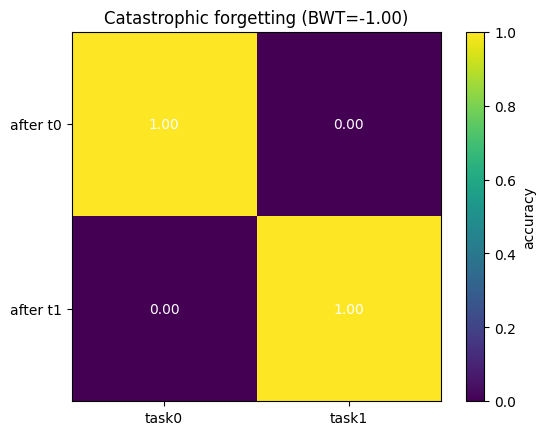

In [3]:
plt.imshow(bench.R_, vmin=0, vmax=1, cmap='viridis')
for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{bench.R_[i,j]:.2f}', ha='center', va='center', color='w')
plt.xticks([0,1],['task0','task1']); plt.yticks([0,1],['after t0','after t1'])
plt.colorbar(label='accuracy'); plt.title(f"Catastrophic forgetting (BWT={bench.metrics_['bwt']:.2f})"); plt.show()

### Conceptors are forgetting-free
Each class gets its own conceptor `C = R(R+a⁻²I)⁻¹` from that class's reservoir states. Because a conceptor depends only on its own class, learning a new class **cannot alter** an earlier one.

In [4]:
import random, pandas as pd
from reservoirs.random import Reservoir
df = pd.get_dummies(pd.read_csv('iris.csv', index_col=0)); raw = df.to_numpy().astype(float)
rng = random.Random(7)
tr = rng.sample(range(0,50),40)+rng.sample(range(50,100),40)+rng.sample(range(100,150),40)
te = [i for i in range(150) if i not in tr]
data = raw.copy(); data[:,:4] = data[:,:4]/data[tr,:4].max(0)
ts = np.arange(0,50,1.0)
u = np.array([np.vstack([np.sin(ts*2*np.pi*p[i]) for i in range(4)]).T for p in data[:,:4]])
labels = data[:,4:].argmax(1)
np.random.seed(7); res = Reservoir(4, 80, rhow=1.25)
states = np.stack([res.forward(s, collect_states=True) for s in u])   # [150,T,80]
print('reservoir states:', states.shape)
from reservoirs.learning import ConceptorClassifier
S_tr, y_tr, S_te, y_te = states[tr], labels[tr], states[te], labels[te]
clf = ConceptorClassifier(aperture=8.0); c0_after = []
for c in [0,1,2]:
    clf.learn_class(S_tr[y_tr==c], c)
    if 0 in clf.conceptors_: c0_after.append(clf.conceptors_[0].copy())
drift = [float(np.abs(c0_after[k]-c0_after[0]).max()) for k in range(len(c0_after))]
print('max change in the class-0 conceptor as classes 1 and 2 are added:', drift)
print('conceptor classifier test accuracy:', round(float(np.mean(clf.predict(S_te)==y_te)),3))

reservoir states: (150, 50, 80)
max change in the class-0 conceptor as classes 1 and 2 are added: [0.0, 0.0, 0.0]
conceptor classifier test accuracy: 0.7


**Takeaway:** the naive online readout forgot task 0 entirely (BWT=−1); the conceptor representation for class 0 is **byte-identical** before and after later classes are added (drift = 0). `cl_metrics` makes forgetting measurable; conceptors are one principled way to avoid it. (Conceptor *decisions* can still shift as competing classes are added — that is the separate class-incremental difficulty, distinct from representation forgetting.)